In [23]:
library(ggplot2)
library(ggrepel)
library(ComplexHeatmap)
library(circlize)
#cas9 senza replica 3
cas9_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cetux_vs_egf_no3/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
cas9<-read.table(cas9_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)

creni_path_322<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/322_combo_vs_EGF/trattamento_cutoff0.05-Combo_72h.vs.EGF0.1.deseq2.tsv'
creni<-read.table(creni_path_322,stringsAsFactors = FALSE, header = TRUE,row.names = 1)
ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cloni_cetux_vs_egf/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
ko<-read.table(ko_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)

In [24]:
th_padj<-0.05
th_log2fc<-0
colonne<-c('log2FoldChange','pvalue','padj')
cinque<-c("ATOH1","LEF1","GFI1","DLL1","DEFA5","DEFA6","OLFM4","NOTCH1","NOTCH2","HES1","DLL4","APCDD1","WNT6","LGR5","FGFR3","FGFR1","FGFR2","FGF20","FGF23","SMAD1","LYZ","SPDEF","CREB3L4")

In [25]:
cas9<-cas9[cinque,colonne]
ko<-ko[cinque,colonne]
creni<-creni[cinque,colonne]
colnames(creni)<-paste0(colnames(creni),'_combo')
colnames(ko)<-paste0(colnames(ko),'_cloni')
colnames(cas9)<-paste0(colnames(cas9),'_cas9')

fenocopia<-merge(creni,ko,by='row.names')
rownames(fenocopia)<-fenocopia$Row.names
fenocopia$Row.names<-NULL
fenocopia<-merge(fenocopia,cas9,by='row.names')
rownames(fenocopia)<-fenocopia$Row.names
fenocopia$Row.names<-NULL
#########################################
######################################
nes_cols <- c("log2FoldChange_combo", "log2FoldChange_cloni","log2FoldChange_cas9")
pval_cols <- setdiff(colnames(fenocopia), nes_cols)
limite <- max((fenocopia))


mat_nes <- fenocopia[, nes_cols]
mat_pval <- fenocopia[, pval_cols]

mat_nes<-as.matrix(mat_nes)
limite <- max((mat_nes), na.rm = TRUE)
#colorRampPalette(c("blue","white","red"))(100)

colori<-col_fun <- colorRamp2(
  c(-limite, 0, limite),
  c("#4575b4", "white", "#d73027")  
)

pdf 
  2

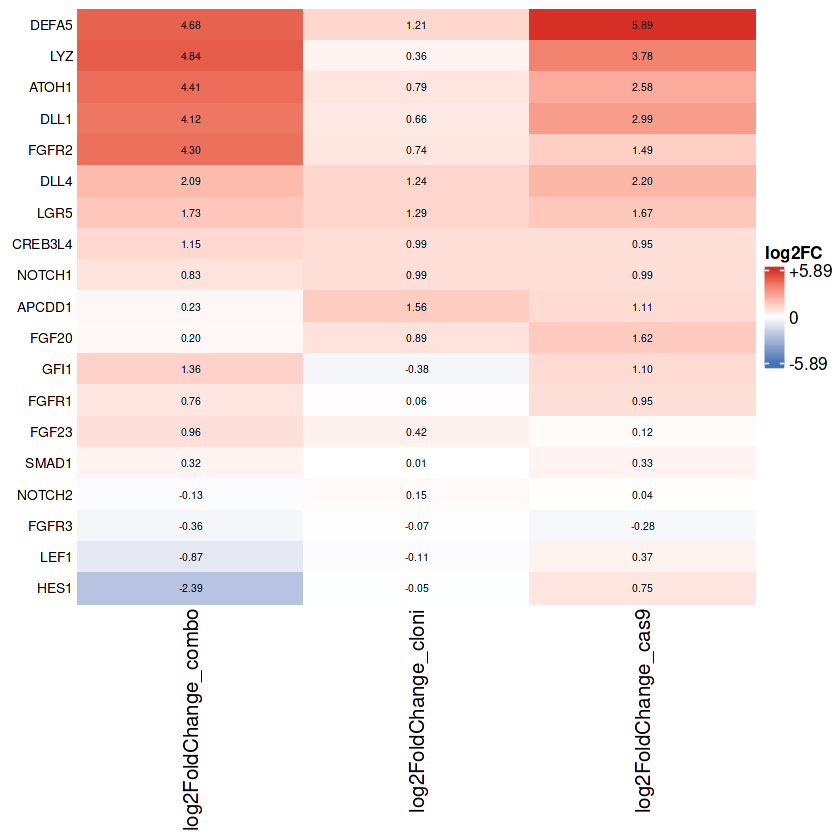

In [30]:
ht_nes <- Heatmap(
  mat_nes,
  name = "log2FC",
  col = colori,
  cluster_columns = FALSE,
  cluster_rows = TRUE,
  show_row_dend = FALSE,
  show_row_names = TRUE,
  row_names_side = "left",
  row_names_gp = gpar(fontsize = 8),
  row_names_max_width = unit(12, "cm"),
  heatmap_legend_param = list(
    at = c(-limite, 0, limite),
    labels = c(paste0("-", round(limite, 2)), "0", paste0("+", round(limite, 2)))
  ),
  cell_fun = function(j, i, x, y, w, h, fill) {
    grid.text(sprintf("%.2f", mat_nes[i, j]), x, y, gp = gpar(fontsize = 6))
  }
)

print(ht_nes)


mat_pval<-as.matrix(mat_pval)
pval_th<-0.05
mat_pval_cat <- ifelse(mat_pval < pval_th, "significativo", "non significativo")
mat_pval_cat[is.na(mat_pval)] <- "NA" 

mat_pval_cat <- as.matrix(mat_pval_cat)
ordered_columns <- c(
  grep("_combo$", colnames(mat_pval_cat), value = TRUE),
  grep("_cloni$", colnames(mat_pval_cat), value = TRUE),
  grep("_cas9",colnames(mat_pval_cat),value = TRUE)
)


mat_pval_cat <- mat_pval_cat[, ordered_columns]

colori_pval <- c("significativo" = "goldenrod", "non significativo" = "lightgrey", "NA" = "white")


ht_pval <- Heatmap(mat_pval_cat,
                   name = "p-value",
                   cluster_rows = FALSE,
                   cluster_columns = FALSE,
                   show_row_names = FALSE,
                   col = colori_pval,
                   rect_gp = gpar(col = "white", lwd = 1),
                   heatmap_legend_param = list(
                     at = c("significativo", "non significativo", "NA"),
                     labels = c(paste0("<", pval_th), paste0(">=", pval_th), "NA")
                   ))

pdf("heatmap_Paneth_cc.pdf", width = 10, height = 8)

# Disegna la figura
draw(ht_nes + ht_pval, heatmap_legend_side = "right")

# Chiudi il PDF
dev.off()

